# Тема 4: «Решение краевой задачи для обыкновенного дифференциального уравнения второго порядка»

### Вариант 6

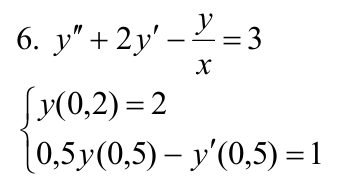
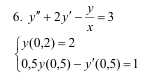

In [ ]:
import math
import matplotlib.pyplot as plt

def linspace(a, b, n):
    """Равномерная сетка из n точек на [a, b]."""
    return [a + i * (b - a) / (n - 1) for i in range(n)]

def simpson(f, a, b, n=200):
    
    """Составная формула Симпсона для ∫_a^b f(x) dx (замена scipy.quad)."""
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    s = f(a) + f(b)
    for i in range(1, n):
        xi = a + i * h
        s += (4 if i % 2 == 1 else 2) * f(xi)
    return s * h / 3

def thomas(a, b, c, d):
    """
    Метод скалярной прогонки для трёхдиагональной СЛАУ:
      a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i]
    a[0] и c[-1] не используются.
    """
    n = len(d)
    c_ = [0.0] * n
    d_ = [0.0] * n
    x  = [0.0] * n

    c_[0] = c[0] / b[0]
    d_[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * c_[i - 1]
        c_[i] = c[i] / denom if i < n - 1 else 0.0
        d_[i] = (d[i] - a[i] * d_[i - 1]) / denom

    x[-1] = d_[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_[i] - c_[i] * x[i + 1]
    return x

---
## Вспомогательные функции

### `linspace(a, b, n)`
Строит список из **n** равноотстоящих точек на отрезке $[a, b]$:
$$x_i = a + i \cdot \frac{b-a}{n-1}, \quad i = 0, 1, \ldots, n-1$$
Шаг сетки: $h = \dfrac{b-a}{n-1}$.

---

### `simpson(f, a, b, n=200)`
Вычисляет определённый интеграл $\displaystyle\int_a^b f(x)\,dx$ **составной формулой Симпсона**.

Отрезок $[a,b]$ разбивается на $n$ равных частей ($n$ чётное) с шагом $h = (b-a)/n$. Формула:
$$\int_a^b f(x)\,dx \approx \frac{h}{3}\bigl[f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \cdots + 4f(x_{n-1}) + f(x_n)\bigr]$$

Коэффициенты чередуются: **4** для нечётных узлов, **2** для чётных (кроме концов). Погрешность — $O(h^4)$.

> Эта функция заменяет `scipy.integrate.quad`, которая делает то же самое, но автоматически подбирает шаг (адаптивный метод Гаусса–Кронрода).

---

### `thomas(a, b, c, d)` — метод скалярной прогонки

Решает **трёхдиагональную** систему уравнений вида:
$$a_i \cdot y_{i-1} + b_i \cdot y_i + c_i \cdot y_{i+1} = d_i, \quad i = 0, \ldots, n-1$$

**Шаг 1 — прямой ход** (вычисление прогоночных коэффициентов $\xi_i$, $\eta_i$):
$$\xi_0 = -\frac{c_0}{b_0}, \quad \eta_0 = \frac{d_0}{b_0}$$
$$\xi_i = \frac{-c_i}{b_i + a_i \xi_{i-1}}, \quad \eta_i = \frac{d_i - a_i \eta_{i-1}}{b_i + a_i \xi_{i-1}}$$

Смысл: каждое уравнение выражает $y_i = \xi_i \cdot y_{i+1} + \eta_i$ (подстановка снизу-вверх).

**Шаг 2 — обратный ход** (восстановление решения справа налево):
$$y_{n-1} = \eta_{n-1}, \quad y_i = \xi_i \cdot y_{i+1} + \eta_i$$

Условие устойчивости: $|b_i| \geq |a_i| + |c_i|$ (диагональное преобладание).

---
## Задание 1. Тестовая задача — интегро-интерполяционный метод (11 узлов)

**Задача Дирихле:**
$$y'' + x\,y' - 2y = 2, \quad y(0) = 0,\quad y(1) = 1, \qquad \text{точное решение: } y_t = x^2$$

---

### Шаг 1. Приведение к самосопряжённой форме

Умножим уравнение на интегрирующий множитель $\mu(x) = e^{\int x\,dx} = e^{x^2/2}$:

$$e^{x^2/2}y'' + x\,e^{x^2/2}y' - 2e^{x^2/2}y = 2e^{x^2/2}$$

Замечаем: $\bigl(e^{x^2/2}y'\bigr)' = e^{x^2/2}y'' + x\,e^{x^2/2}y'$, поэтому:

$$\underbrace{\bigl(e^{x^2/2}y'\bigr)'}_{(k\,y')'} - \underbrace{2e^{x^2/2}}_{q}\cdot y + \underbrace{(-2e^{x^2/2})}_{f} = 0$$

Итого: $k(x) = e^{x^2/2}$, $\quad q(x) = 2e^{x^2/2}$, $\quad f(x) = -2e^{x^2/2}$

---

### Шаг 2. Коэффициенты схемы (§8.6.1)

Узлы $x_i = ih$, $h = 1/(n-1)$. Полуцелые точки: $x_{i\pm 1/2} = x_i \pm h/2$.

$$\alpha_i = \left(\frac{1}{h}\int_{x_{i-1}}^{x_i}\frac{dx}{k(x)}\right)^{-1} \approx \frac{2}{\dfrac{1}{k(x_{i-1})} + \dfrac{1}{k(x_i)}} \quad \text{(формула трапеций)}$$

$$d_i = \frac{1}{h}\int_{x_{i-1/2}}^{x_{i+1/2}} q(x)\,dx \approx q(x_i) \quad \text{(формула прямоугольника)}$$

$$\varphi_i = \frac{1}{h}\int_{x_{i-1/2}}^{x_{i+1/2}} f(x)\,dx \approx f(x_i) \quad \text{(формула прямоугольника)}$$

---

### Шаг 3. Разностная схема

$$\bigl(\alpha\,y_{\bar{x}}\bigr)_{x,i} - d_i\,y_i + \varphi_i = 0, \quad i = \overline{1, n-1}$$

Раскрывая $(\alpha\,y_{\bar x})_{x,i} = \dfrac{\alpha_{i+1}(y_{i+1}-y_i) - \alpha_i(y_i-y_{i-1})}{h^2}$ и умножая на $h^2$:

$$\underbrace{\alpha_i}_{A_i}\,y_{i-1} - \underbrace{(\alpha_i+\alpha_{i+1}+d_i h^2)}_{C_i}\,y_i + \underbrace{\alpha_{i+1}}_{B_i}\,y_{i+1} = \underbrace{-\varphi_i h^2}_{-F_i}$$

Система в обозначениях учебника: $A_i y_{i-1} - C_i y_i + B_i y_{i+1} = -F_i$

Условие устойчивости: $C_i = A_i + B_i + d_i h^2 \geq A_i + B_i$ ✓ (т.к. $d_i \geq 0$)

---

### Перевод в формат метода прогонки

Умножаем на $(-1)$: $-A_i\,y_{i-1} + C_i\,y_i - B_i\,y_{i+1} = F_i$

В нашей функции `thomas(a, b, c, d)`: $a_i = A_i$, $b_i = -C_i$, $c_i = B_i$, $d_i = -F_i = \varphi_i h^2$

x         МКР       Точное    Погрешность
----------------------------------------------
0.0       0.000000  0.000000  0.00e+00
0.1       0.010186  0.010000  1.86e-04
0.2       0.040325  0.040000  3.25e-04
0.3       0.090417  0.090000  4.17e-04
0.4       0.160467  0.160000  4.67e-04
0.5       0.250475  0.250000  4.75e-04
0.6       0.360444  0.360000  4.44e-04
0.7       0.490377  0.490000  3.77e-04
0.8       0.640278  0.640000  2.78e-04
0.9       0.810151  0.810000  1.51e-04
1.0       1.000000  1.000000  0.00e+00


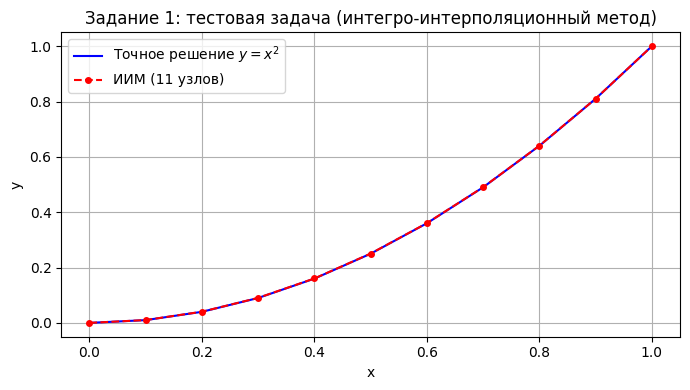

In [20]:
def solve_task1(n=11):
    """
    Интегро-интерполяционный метод для (k·y')' - q·y + f = 0 на [0,1].
    k = e^{x²/2},  q = 2·e^{x²/2},  f = -2·e^{x²/2}
    ГУ Дирихле: y(0)=0, y(1)=1.
    """
    h = 1.0 / (n - 1)
    x = linspace(0.0, 1.0, n)
    y0, yn = 0.0, 1.0

    def k(xi): return math.exp(xi**2 / 2)
    def q(xi): return 2 * math.exp(xi**2 / 2)
    def f(xi): return -2 * math.exp(xi**2 / 2)

    # α_i = формула трапеций для (1/h·∫ dx/k)^{-1}
    # = 2 / (1/k(x_{i-1}) + 1/k(x_i))
    alpha = [0.0] * (n + 1)
    for i in range(1, n):
        alpha[i] = 2.0 / (1.0/k(x[i-1]) + 1.0/k(x[i]))

    # Неизвестные y[1],...,y[n-2]  →  m = n-2 уравнений
    m = n - 2
    a = [0.0]*m;  b = [0.0]*m;  c = [0.0]*m;  d = [0.0]*m

    for ki in range(m):
        i = ki + 1
        A_i = alpha[i]
        B_i = alpha[i + 1]
        C_i = alpha[i] + alpha[i+1] + q(x[i]) * h**2   # диагональный элемент
        F_i = f(x[i]) * h**2                            # правая часть φ_i·h²

        # thomas: a·y_{i-1} + b·y_i + c·y_{i+1} = d
        # из A·y_{i-1} - C·y_i + B·y_{i+1} = -F  (умножение на -1)
        a[ki] = A_i if ki > 0 else 0.0
        b[ki] = -C_i                  # отрицательный — диагональное преобладание
        c[ki] = B_i if ki < m-1 else 0.0
        d[ki] = -F_i                  # -F_i = -φ_i·h² = 2·e^{x_i²/2}·h²

        if ki == 0:     d[ki] -= A_i * y0   # A_1·y_0 перенос в правую часть
        if ki == m - 1: d[ki] -= B_i * yn   # B_{n-2}·y_{n-1} перенос в правую часть

    y_inner = thomas(a, b, c, d)
    y       = [y0] + y_inner + [yn]
    y_exact = [xi**2 for xi in x]
    return x, y, y_exact


x1, y_fdm1, y_ex1 = solve_task1(n=11)

print("x         МКР       Точное    Погрешность")
print("-" * 46)
for xi, yi, ye in zip(x1, y_fdm1, y_ex1):
    print(f"{xi:.1f}       {yi:.6f}  {ye:.6f}  {abs(yi - ye):.2e}")

plt.figure(figsize=(7, 4))
plt.plot(x1, y_ex1,  'b-',    label='Точное решение $y=x^2$')
plt.plot(x1, y_fdm1, 'r--o',  markersize=4, label='ИИМ (11 узлов)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Задание 1: тестовая задача (интегро-интерполяционный метод)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

---
## Задание 2. Вариант 6 — интегро-интерполяционный метод (11, 51, 101 узлов)

**Краевая задача:**
$$y'' + 2y' - \frac{y}{x} = 3, \quad x \in [0{,}2;\;0{,}5]$$
$$y(0{,}2) = 2 \;\text{(Дирихле)}, \qquad 0{,}5\,y(0{,}5) - y'(0{,}5) = 1 \;\text{(Ньютона)}$$

---

### Шаг 1. Приведение к самосопряжённой форме

Интегрирующий множитель: $\mu(x) = e^{\int 2\,dx} = e^{2x}$.

$$\bigl(e^{2x}y'\bigr)' - \frac{e^{2x}}{x}\,y + (-3e^{2x}) = 0$$

Итого: $k(x) = e^{2x}$, $\quad q(x) = \dfrac{e^{2x}}{x}$, $\quad f(x) = -3e^{2x}$

---

### Шаг 2. Коэффициенты схемы

Те же формулы §8.6.1 (трапеции + прямоугольник), но теперь $1/k(x) = e^{-2x}$.

$$\alpha_i = \frac{2}{e^{-2x_{i-1}} + e^{-2x_i}}, \qquad d_i = \frac{e^{2x_i}}{x_i}, \qquad \varphi_i = -3e^{2x_i}$$

---

### Шаг 3. Правое краевое условие Ньютона — метод фиктивного узла

Условие: $0{,}5\,y_N - y'_N = 1$, где $N = n-1$.

Вводим фиктивный узел $x_{N+1} = x_N + h$. Из центральной разности $y'_N \approx \dfrac{y_{N+1}-y_{N-1}}{2h}$:
$$y_{N+1} = y_{N-1} + h\,y_N - 2h$$

Подставляем в схему ИИМ для узла $N$:
$$A_N\,y_{N-1} - C_N\,y_N + B_N\,y_{N+1} = -F_N$$

$$\Downarrow$$

$$\underbrace{(A_N+B_N)}_{a}\,y_{N-1} + \underbrace{(B_N h - C_N)}_{b}\,y_N = -F_N + 2h\,B_N$$

где $B_N = \alpha_{N+1}$ — коэффициент на фиктивном интервале $[x_N, x_{N+1}]$.

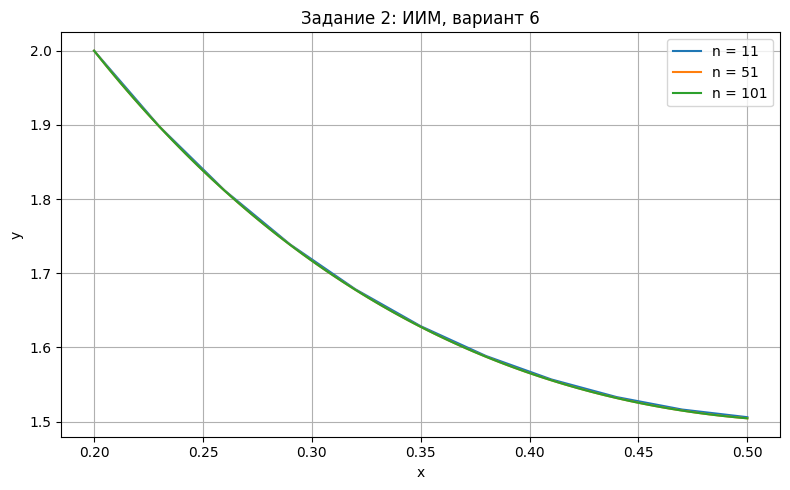

n=11:  x       y
----------------------
       0.2000  2.000000
       0.2300  1.897879
       0.2600  1.811536
       0.2900  1.738931
       0.3200  1.678415
       0.3500  1.628628
       0.3800  1.588427
       0.4100  1.556842
       0.4400  1.533035
       0.4700  1.516281
       0.5000  1.505942


In [21]:
def solve_task2(n):
    """
    Интегро-интерполяционный метод для (k·y')' - q·y + f = 0 на [0.2, 0.5].
    k = e^{2x},  q = e^{2x}/x,  f = -3·e^{2x}
    Левая ГУ Дирихле: y(0.2)=2.
    Правая ГУ Ньютона: 0.5·y(0.5) - y'(0.5) = 1  (метод фиктивного узла).
    """
    h = 0.3 / (n - 1)
    x = linspace(0.2, 0.5, n)
    y0 = 2.0

    def k(xi): return math.exp(2 * xi)
    def q(xi): return math.exp(2 * xi) / xi
    def f(xi): return -3 * math.exp(2 * xi)

    # α_i трапецией: 2 / (1/k(x_{i-1}) + 1/k(x_i)) = 2/(e^{-2x_{i-1}}+e^{-2x_i})
    alpha = [0.0] * (n + 1)
    for i in range(1, n):
        alpha[i] = 2.0 / (1.0/k(x[i-1]) + 1.0/k(x[i]))
    # α_{N+1} для фиктивного интервала [x_N, x_N+h]
    x_ghost = x[n-1] + h
    alpha[n] = 2.0 / (1.0/k(x[n-1]) + 1.0/k(x_ghost))

    # Неизвестные: y[1],...,y[n-1]  →  m = n-1
    m = n - 1
    a = [0.0]*m;  b = [0.0]*m;  c = [0.0]*m;  d = [0.0]*m

    # Внутренние узлы i = 1,...,n-2  →  ki = 0,...,m-2
    for ki in range(m - 1):
        i = ki + 1
        A_i = alpha[i]
        B_i = alpha[i + 1]
        C_i = alpha[i] + alpha[i+1] + q(x[i]) * h**2
        F_i = f(x[i]) * h**2          # φ_i·h²

        a[ki] = A_i if ki > 0 else 0.0
        b[ki] = -C_i
        c[ki] = B_i
        d[ki] = -F_i
        if ki == 0: d[ki] -= A_i * y0   # учёт левого ГУ Дирихле

    # Последняя строка: узел N = n-1 (ГУ Ньютона через фиктивный узел)
    ki = m - 1
    N  = n - 1
    A_N = alpha[N]       # α_N
    B_N = alpha[n]       # α_{N+1} (фиктивный)
    C_N = A_N + B_N + q(x[N]) * h**2
    F_N = f(x[N]) * h**2

    # (A_N+B_N)·y_{N-1} + (B_N·h - C_N)·y_N = -F_N + 2h·B_N
    a[ki] = A_N + B_N
    b[ki] = B_N * h - C_N        # < 0 при малых h (диагональное преобладание)
    c[ki] = 0.0
    d[ki] = -F_N + 2 * h * B_N   # = 3·e^{2x_N}·h² + 2h·α_{N+1}

    y_inner = thomas(a, b, c, d)
    return x, [y0] + y_inner


grids = [11, 51, 101]
results2 = {}

plt.figure(figsize=(8, 5))
for n in grids:
    xg, yg = solve_task2(n)
    results2[n] = (xg, yg)
    plt.plot(xg, yg, label=f'n = {n}')

plt.xlabel('x'); plt.ylabel('y')
plt.title('Задание 2: ИИМ, вариант 6')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("n=11:  x       y")
print("-" * 22)
for xi, yi in zip(*results2[11]):
    print(f"       {xi:.4f}  {yi:.6f}")

In [22]:
def interp(x_known, y_known, xi):
    """Линейная интерполяция в точке xi по известным (x_known, y_known)."""
    for j in range(len(x_known) - 1):
        if x_known[j] <= xi <= x_known[j + 1] + 1e-12:
            t = (xi - x_known[j]) / (x_known[j + 1] - x_known[j])
            return y_known[j] + t * (y_known[j + 1] - y_known[j])
    return y_known[-1]

# Общие точки — узлы грубой сетки n=11
x_cmp = results2[11][0]

# Интерполируем решения n=51 и n=101 в эти точки
rows = {}
for n in [11, 51, 101]:
    xn, yn = results2[n]
    rows[n] = [interp(xn, yn, xi) for xi in x_cmp]

# Вывод таблицы
header = f"{'x':>8}" + "".join(f"  {'n='+str(n):>12}" for n in [11, 51, 101]) + f"  {'max|diff|':>12}"
print(header)
print("-" * len(header))

for i, xi in enumerate(x_cmp):
    vals = [rows[n][i] for n in [11, 51, 101]]
    max_diff = max(vals) - min(vals)
    row = f"{xi:8.4f}" + "".join(f"  {v:12.8f}" for v in vals) + f"  {max_diff:.4e}"
    print(row)

# Максимальная разница по всем точкам
all_diffs = [max(rows[n][i] for n in [11,51,101]) - min(rows[n][i] for n in [11,51,101])
             for i in range(len(x_cmp))]
print(f"\nМакс. расхождение между сетками: {max(all_diffs):.4e}")
print(f"Отношение шагов h₁₁/h₅₁ = {10/50:.4f}  → ожидаемое улучшение: ~{(10/50)**2:.0f}x (порядок O(h²))")

       x          n=11          n=51         n=101     max|diff|
----------------------------------------------------------------
  0.2000    2.00000000    2.00000000    2.00000000  0.0000e+00
  0.2300    1.89787863    1.89764353    1.89763616  2.4247e-04
  0.2600    1.81153596    1.81110155    1.81108794  4.4802e-04
  0.2900    1.73893100    1.73832193    1.73830285  6.2815e-04
  0.3200    1.67841514    1.67764917    1.67762518  7.8996e-04
  0.3500    1.62862793    1.62771831    1.62768982  9.3810e-04
  0.3800    1.58842744    1.58738438    1.58735172  1.0757e-03
  0.4100    1.55684194    1.55567351    1.55563693  1.2050e-03
  0.4400    1.53303518    1.53174788    1.53170759  1.3276e-03
  0.4700    1.51628064    1.51487986    1.51483601  1.4446e-03
  0.5000    1.50594217    1.50443240    1.50438515  1.5570e-03

Макс. расхождение между сетками: 1.5570e-03
Отношение шагов h₁₁/h₅₁ = 0.2000  → ожидаемое улучшение: ~0x (порядок O(h²))


---
## Задание 3. Вариант 6 — метод Галёркина (полиномы, $n=2$)

### Идея метода

Ищем **приближённое** решение в виде конечной суммы:
$$\tilde{y}(x) = u(x) + \sum_{i=1}^{n} c_i\,\varphi_i(x)$$

- $u(x)$ — **частное решение**, удовлетворяющее исходным (неоднородным) краевым условиям.
- $\varphi_i(x)$ — **базисные функции**, удовлетворяющие **однородным** краевым условиям.
- $c_i$ — неизвестные коэффициенты.

### Шаг 1: нахождение $u(x)$

Ищем в виде $u = A x + B$. Подставляем в оба ГУ:
$$u(0{,}2) = 2 \implies 0{,}2A + B = 2$$
$$0{,}5\,u(0{,}5) - u'(0{,}5) = 1 \implies 0{,}25A + 0{,}5B - A = 1 \implies -0{,}75A + 0{,}5B = 1$$

Из системы: $A = 0$, $B = 2$ → $\boxed{u(x) \equiv 2}$

### Шаг 2: построение базисных функций

$\varphi_i$ должны обнулять оба однородных ГУ:
- $\varphi_i(0{,}2) = 0$
- $0{,}5\,\varphi_i(0{,}5) - \varphi_i'(0{,}5) = 0$

**$\varphi_1(x) = (x-0{,}2)(x-r)$** — квадратный полином, автоматически $\varphi_1(0{,}2)=0$.

Из второго условия: $0{,}5 \cdot 0{,}3(0{,}5-r) - (0{,}8-r) = 0 \implies r = \dfrac{29}{34} \approx 0{,}853$

**$\varphi_2(x) = (x-0{,}2)^2(x-s)$** — кубический полином, двойной нуль в $x=0{,}2$.

Из второго условия: $s = \dfrac{49}{74} \approx 0{,}662$

### Шаг 3: система Галёркина

Невязка: $R(x) = \mathcal{L}[\tilde{y}] - f = \mathcal{L}[u] - f + \sum_i c_i\,\mathcal{L}[\varphi_i]$, где $\mathcal{L}[y] = y'' + 2y' - y/x$.

Условие Галёркина — невязка **ортогональна** каждой базисной функции:
$$\int_{0.2}^{0.5} R(x)\,\varphi_j(x)\,dx = 0, \quad j = 1, 2$$

Это даёт линейную систему $K\,\mathbf{c} = \mathbf{F}$:
$$K_{ji} = \int_{0.2}^{0.5} \mathcal{L}[\varphi_i]\cdot\varphi_j\,dx, \qquad F_j = \int_{0.2}^{0.5} \bigl(f - \mathcal{L}[u]\bigr)\cdot\varphi_j\,dx$$

Так как $u=2$: $\mathcal{L}[u] = -2/x$, поэтому $f - \mathcal{L}[u] = 3 + 2/x$.

### Шаг 4: решение системы $2\times 2$ (правило Крамера)

$$c_1 = \frac{F_0 K_{11} - F_1 K_{01}}{\det K}, \qquad c_2 = \frac{K_{00} F_1 - K_{10} F_0}{\det K}$$

### Итоговое приближение
$$\tilde{y}(x) = 2 + c_1\,\varphi_1(x) + c_2\,\varphi_2(x)$$

In [23]:
# --- Базисные функции (скалярные, без NumPy) ---
r = 29 / 34   # корень phi1
s = 49 / 74   # корень phi2

print(f"r = {r:.6f},  s = {s:.6f}")

def phi1(x):   return (x - 0.2) * (x - r)
def phi1_p(x): return 2*x - 0.2 - r
def phi1_pp(x): return 2.0

def phi2(x):   return (x - 0.2)**2 * (x - s)
def phi2_p(x): return 2*(x - 0.2)*(x - s) + (x - 0.2)**2
def phi2_pp(x): return 2*(x - s) + 4*(x - 0.2)

# Проверка граничных условий (должны быть ≈ 0)
for name, ph, ph_p in [('φ₁', phi1, phi1_p), ('φ₂', phi2, phi2_p)]:
    v_left = ph(0.2)
    robin  = 0.5 * ph(0.5) - ph_p(0.5)
    print(f"{name}(0.2) = {v_left:.2e}  |  0.5·{name}(0.5) - {name}'(0.5) = {robin:.2e}")

r = 0.852941,  s = 0.662162
φ₁(0.2) = -0.00e+00  |  0.5·φ₁(0.5) - φ₁'(0.5) = -6.94e-17
φ₂(0.2) = -0.00e+00  |  0.5·φ₂(0.5) - φ₂'(0.5) = 8.67e-18


### Пояснение к коду базисных функций

**`phi1(x)`, `phi2(x)`** — значения базисных функций:
- `phi1(x) = (x-0.2)*(x-r)` — квадратный двучлен
- `phi2(x) = (x-0.2)**2*(x-s)` — кубический двучлен

**`phi1_p`, `phi2_p`** — первые производные (нужны для оператора $\mathcal{L}$ и проверки ГУ):
- `phi1_p(x) = 2x - 0.2 - r` (производная квадратичного двучлена)
- `phi2_p(x) = 2(x-0.2)(x-s) + (x-0.2)²` (по правилу произведения)

**`phi1_pp`, `phi2_pp`** — вторые производные:
- `phi1_pp(x) = 2` (постоянная — квадратный полином)
- `phi2_pp(x) = 2(x-s) + 4(x-0.2)` (производная от `phi2_p`)

**Проверка ГУ**: выводим $\varphi_i(0{,}2)$ и $0{,}5\varphi_i(0{,}5)-\varphi_i'(0{,}5)$ — оба должны быть $\approx 0$.

In [24]:
# --- Оператор L[y] = y'' + 2y' - y/x ---
def L_phi1(x): return phi1_pp(x) + 2*phi1_p(x) - phi1(x)/x
def L_phi2(x): return phi2_pp(x) + 2*phi2_p(x) - phi2(x)/x

# L[u] = -2/x  (u=2, u'=0, u''=0)  →  f - L[u] = 3 + 2/x

phis  = [phi1,  phi2]
Lphis = [L_phi1, L_phi2]

a_dom, b_dom = 0.2, 0.5

# Матрица K и вектор F (интегралы — формула Симпсона)
K = [[0.0, 0.0], [0.0, 0.0]]
F = [0.0, 0.0]

for j in range(2):
    for i in range(2):
        K[j][i] = simpson(lambda x, i=i, j=j: Lphis[i](x) * phis[j](x), a_dom, b_dom)
    F[j] = simpson(lambda x, j=j: (3 + 2/x) * phis[j](x), a_dom, b_dom)

print("Матрица K:")
for row in K: print(f"  [{row[0]:10.6f}  {row[1]:10.6f}]")
print(f"Вектор F: [{F[0]:.6f},  {F[1]:.6f}]")

# Решение 2x2 системы методом Крамера
det  = K[0][0]*K[1][1] - K[0][1]*K[1][0]
c1   = (F[0]*K[1][1] - F[1]*K[0][1]) / det
c2   = (K[0][0]*F[1] - K[1][0]*F[0]) / det
c_gal = [c1, c2]

print(f"\nКоэффициенты:  c1 = {c1:.6f},  c2 = {c2:.6f}")

Матрица K:
  [ -0.033777   -0.002626]
  [ -0.003741   -0.000567]
Вектор F: [-0.170295,  -0.017077]

Коэффициенты:  c1 = 5.544926,  c2 = -6.472119


### Пояснение к коду: матрица K и вектор F

**`L_phi1(x)`, `L_phi2(x)`** — применение оператора $\mathcal{L}[y] = y'' + 2y' - y/x$ к базисным функциям:
```
L_phi1(x) = phi1_pp(x) + 2*phi1_p(x) - phi1(x)/x
           = 2         + 2*(2x-0.2-r)  - (x-0.2)(x-r)/x
```

**Заполнение матрицы K (двойной цикл):**
- `K[j][i] = ∫ L[φᵢ]·φⱼ dx` — интеграл считается формулой Симпсона
- `j` — номер строки (весовая функция $\varphi_j$)
- `i` — номер столбца (к какой базисной функции применяем $\mathcal{L}$)

**Заполнение вектора F:**
- `F[j] = ∫ (3 + 2/x)·φⱼ dx` — правая часть ($f - \mathcal{L}[u] = 3 + 2/x$)

**Решение `K·c = F` правилом Крамера:**
$$\det K = K_{00}K_{11} - K_{01}K_{10}$$
$$c_1 = \frac{F_0 K_{11} - F_1 K_{01}}{\det K}, \quad c_2 = \frac{K_{00} F_1 - K_{10} F_0}{\det K}$$

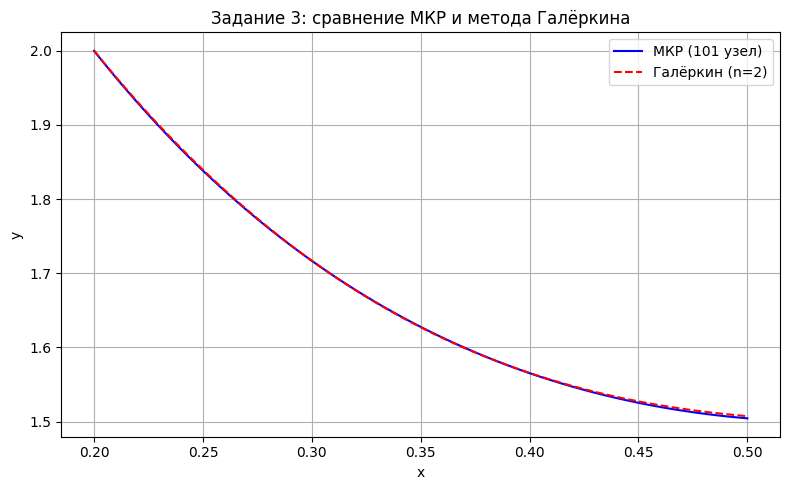

       x         МКР    Галёркин    |разность|
----------------------------------------------
  0.2000    2.000000    2.000000      0.00e+00
  0.2300    1.897879    1.898892      1.01e-03
  0.2600    1.811536    1.812101      5.65e-04
  0.2900    1.738931    1.738578      3.53e-04
  0.3200    1.678415    1.677275      1.14e-03
  0.3500    1.628628    1.627142      1.49e-03
  0.3800    1.588427    1.587132      1.30e-03
  0.4100    1.556842    1.556196      6.46e-04
  0.4400    1.533035    1.533286      2.51e-04
  0.4700    1.516281    1.517353      1.07e-03
  0.5000    1.505942    1.507348      1.41e-03


: 

In [ ]:
# --- Сравнение: Галёркин vs МКР (101 узел) ---
x_fine    = linspace(0.2, 0.5, 500)
y_galerkin = [2 + c_gal[0]*phi1(xi) + c_gal[1]*phi2(xi) for xi in x_fine]

x_fdm_ref, y_fdm_ref = results2[101]

plt.figure(figsize=(8, 5))
plt.plot(x_fdm_ref, y_fdm_ref, 'b-',  linewidth=1.5, label='МКР (101 узел)')
plt.plot(x_fine,    y_galerkin, 'r--', linewidth=1.5, label='Галёркин (n=2)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Задание 3: сравнение МКР и метода Галёркина')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Погрешность в узлах n=11
x_11, y_fdm_11 = results2[11]
y_gal_11 = [2 + c_gal[0]*phi1(xi) + c_gal[1]*phi2(xi) for xi in x_11]

print(f"{'x':>8}  {'МКР':>10}  {'Галёркин':>10}  {'|разность|':>12}")
print("-" * 46)
for xi, ym, yg in zip(x_11, y_fdm_11, y_gal_11):
    print(f"{xi:8.4f}  {ym:10.6f}  {yg:10.6f}  {abs(ym - yg):12.2e}")